In [13]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

from src.training import (
    train_resnet, loss_fn_resnet, loss_fn_fa_resnet,
    loss_fn_ea_resnet, loss_fn_da_resnet, DEFAULT_CONFIG_RESNET,
)
from src.teacher import make_wi_particles_resnet, make_arbitrary_particles_resnet
from src.metrics import rmd_to_projected
from src.utils import plot_rmd_curves, plot_particles_3d_resnet
import src.spaces as spaces

spaces.SETUP = spaces.make_setup_matrix()

import plotly.io as pio

L_VALUES = [1, 10, 100, 500]  # ResNet depth (1 skip connection)
N = 3
#N_VALUES = [5, 10, 50, 100, 500]
N_REPS = 3
CONFIG = {**DEFAULT_CONFIG_RESNET, "T": 1.0, "gr": 5}
CONFIG['beta'] = 0.0


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
teacher_wi = make_wi_particles_resnet(1)

results_wi = {"vanilla": [], "DA": [], "FA": [], "EA": []}

for L in L_VALUES:
    for name in results_wi:
        results_wi[name].append([])

    for rep in range(N_REPS):
        key = jax.random.PRNGKey(rep * 1000 + N)

        # Vanilla
        h = train_resnet(teacher_wi, N, L, jax.random.fold_in(key, 0), CONFIG, "si")
        results_wi["vanilla"][-1].append(jnp.mean(jnp.array([rmd_to_projected(layer) for layer in h["particles"][-1]])))

        # DA
        h = train_resnet(teacher_wi, N, L, jax.random.fold_in(key, 1), CONFIG, "si", used_loss_fn=loss_fn_da_resnet)
        results_wi["DA"][-1].append(jnp.mean(jnp.array([rmd_to_projected(layer) for layer in h["particles"][-1]])))

        # FA
        h = train_resnet(teacher_wi, N, L, jax.random.fold_in(key, 2), CONFIG, "si", used_loss_fn=loss_fn_fa_resnet)
        results_wi["FA"][-1].append(jnp.mean(jnp.array([rmd_to_projected(layer) for layer in h["particles"][-1]])))

        # EA
        # h = train_resnet(teacher_wi, N, L, jax.random.fold_in(key, 3), CONFIG, "si", used_loss_fn=loss_fn_ea_resnet)
        # results_wi["EA"][-1].append(jnp.mean(jnp.array([rmd_to_projected(layer) for layer in h["particles"][-1]])))

    print(f"L={L} done")

L=1 done
L=10 done
L=100 done
L=500 done


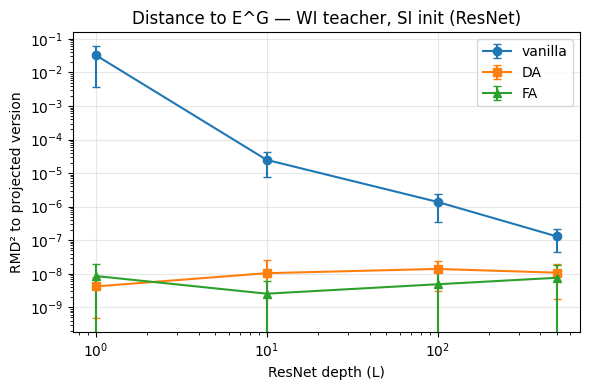

In [16]:
plot_rmd_curves(L_VALUES, results_wi, "ResNet depth (L)", "Distance to E^G — WI teacher, SI init (ResNet)", exclude=['EA'], filename="dist_Eg_matrix_rn_WI.pdf", save_pdf=True)


In [17]:
teacher_arb = make_arbitrary_particles_resnet(1)

results_arb = {"vanilla": [], "DA": [], "FA": [], "EA": []}

for L in L_VALUES:
    for name in results_arb:
        results_arb[name].append([])

    for rep in range(N_REPS):
        key = jax.random.PRNGKey(rep * 1000 + N)

        h = train_resnet(teacher_arb, N, L, jax.random.fold_in(key, 0), CONFIG, "si")
        results_arb["vanilla"][-1].append(jnp.mean(jnp.array([rmd_to_projected(layer) for layer in h["particles"][-1]])))

        h = train_resnet(teacher_arb, N, L, jax.random.fold_in(key, 1), CONFIG, "si", used_loss_fn=loss_fn_da_resnet)
        results_arb["DA"][-1].append(jnp.mean(jnp.array([rmd_to_projected(layer) for layer in h["particles"][-1]])))

        h = train_resnet(teacher_arb, N, L, jax.random.fold_in(key, 2), CONFIG, "si", used_loss_fn=loss_fn_fa_resnet)
        results_arb["FA"][-1].append(jnp.mean(jnp.array([rmd_to_projected(layer) for layer in h["particles"][-1]])))

        # h = train_resnet(teacher_arb, N, L, jax.random.fold_in(key, 3), CONFIG, "si", used_loss_fn=loss_fn_ea_resnet)
        # results_arb["EA"][-1].append(jnp.mean(jnp.array([rmd_to_projected(layer) for layer in h["particles"][-1]])))

    print(f"L={L} done")

L=1 done
L=10 done
L=100 done
L=500 done


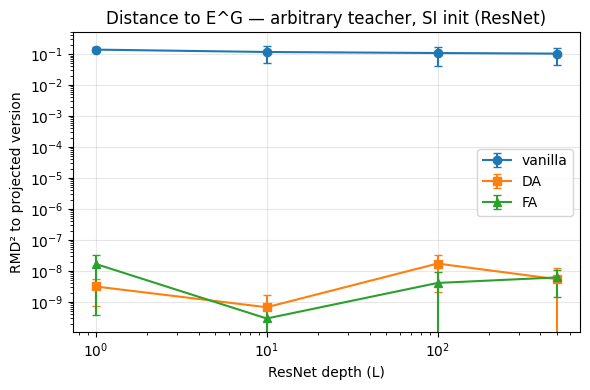

In [18]:
plot_rmd_curves(L_VALUES, results_arb, "ResNet depth (L)", "Distance to E^G — arbitrary teacher, SI init (ResNet)", exclude=['EA'], filename='dist_Eg_rn_matrix_arb.pdf', save_pdf=True)


In [19]:
teacher = make_wi_particles_resnet(1)
N = 5
L = 100
key = jax.random.PRNGKey(42)

configs = {**DEFAULT_CONFIG_RESNET, "T": 4.0, "gr": 10}

h_vanilla = train_resnet(teacher, N, L, jax.random.fold_in(key, 0), configs, "si")
print("vanilla done")
# h_da = train_resnet(teacher, N, L, jax.random.fold_in(key, 1), configs, "si", used_loss_fn=loss_fn_da_resnet)
# print("DA done")
# h_fa = train_resnet(teacher, N, L, jax.random.fold_in(key, 2), configs, "si", used_loss_fn=loss_fn_fa_resnet)
# print("FA done")
# h_ea = train_resnet(teacher, N, L, jax.random.fold_in(key, 3), configs, "si", used_loss_fn=loss_fn_ea_resnet)
# print("EA done")

vanilla done


In [20]:
fig = plot_particles_3d_resnet(h_vanilla["particles"][-1], teacher, "Student Particles — vanilla (ResNet L=100)")

In [21]:
fig.write_image('matrix_rn_vanilla_WI.pdf', scale=3)

In [22]:
fig.write_html('matrix_rn_vanilla_WI.html')

In [ ]:
plot_particles_3d_resnet(h_da["particles"][-1], teacher, "Student Particles — DA (ResNet L=100)")

In [ ]:
plot_particles_3d_resnet(h_fa["particles"][-1], teacher, "Student Particles — FA (ResNet L=100)")

In [ ]:
plot_particles_3d_resnet(h_ea["particles"][-1], teacher, "Student Particles — EA (ResNet L=100)")

In [23]:
teacher_arb2 = make_arbitrary_particles_resnet(1)

N = 5
L = 100
key = jax.random.PRNGKey(42)

h_vanilla_arb = train_resnet(teacher_arb2, N, L, jax.random.fold_in(key, 0), configs, "si")
print("vanilla done")
# h_da_arb = train_resnet(teacher_arb2, N, L, jax.random.fold_in(key, 1), configs, "si", used_loss_fn=loss_fn_da_resnet)
# print("DA done")
# h_fa_arb = train_resnet(teacher_arb2, N, L, jax.random.fold_in(key, 2), configs, "si", used_loss_fn=loss_fn_fa_resnet)
# print("FA done")
# h_ea_arb = train_resnet(teacher_arb2, N, L, jax.random.fold_in(key, 3), configs, "si", used_loss_fn=loss_fn_ea_resnet)
# print("EA done")

vanilla done


In [24]:
fig = plot_particles_3d_resnet(h_vanilla_arb["particles"][-1], teacher_arb2, "Arbitrary teacher — vanilla (ResNet L=100)")

In [27]:
fig.write_image('matrix_rn_vanilla_arb.pdf', scale=3)

In [28]:
fig.write_html('matrix_rn_vanilla_arb.html')

In [ ]:
plot_particles_3d_resnet(h_da_arb["particles"][-1], teacher_arb2, "Arbitrary teacher — DA (ResNet L=100)")

In [ ]:
plot_particles_3d_resnet(h_fa_arb["particles"][-1], teacher_arb2, "Arbitrary teacher — FA (ResNet L=100)")

In [ ]:
plot_particles_3d_resnet(h_ea_arb["particles"][-1], teacher_arb2, "Arbitrary teacher — EA (ResNet L=100)")

In [67]:
import numpy as np

h_vanilla['particles'][-1][0].mean()

Array(-1.6908746, dtype=float32)